# FraudGuard AI — Random Forest

## Objective

Train and evaluate a Random Forest classifier for credit-card fraud detection
and compare its performance with the Logistic Regression benchmark.

Evaluation will focus on:

- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision
- False positives
- False negatives

# Random Forest Evaluation

Random Forest was evaluated using the same train/test split as the Logistic
Regression experiments to enable a fair comparison.

The model was evaluated using precision, recall, F1-score, ROC-AUC,
Average Precision, and the confusion matrix.

Special attention was given to:

- False negatives, representing missed fraud.
- False positives, representing unnecessary fraud alerts.
- Minority-class recall and precision.
- Performance relative to the threshold-tuned Logistic Regression benchmark.

Feature importance was also examined to identify which input features were
most influential in the Random Forest model.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

df = df.drop_duplicates().copy()

In [3]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
Class
0    226602
1       378
Name: count, dtype: int64

Testing:
Class
0    56651
1       95
Name: count, dtype: int64


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [8]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [11]:
rf_pred = rf_model.predict(X_test)


In [12]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [13]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

rf_ap = average_precision_score(
    y_test,
    rf_prob
)

In [14]:
print(f"Accuracy          : {rf_accuracy:.4f}")
print(f"Precision         : {rf_precision:.4f}")
print(f"Recall            : {rf_recall:.4f}")
print(f"F1 Score          : {rf_f1:.4f}")
print(f"ROC-AUC           : {rf_roc_auc:.4f}")
print(f"Average Precision : {rf_ap:.4f}")

Accuracy          : 0.9995
Precision         : 0.9718
Recall            : 0.7263
F1 Score          : 0.8313
ROC-AUC           : 0.9239
Average Precision : 0.7876


In [15]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[56649     2]
 [   26    69]]


In [16]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [17]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (0.50)",
        "Logistic Regression (0.10)",
        "Random Forest (0.50)"
    ],

    "Precision": [
        0.8485,
        0.843373,
        rf_precision
    ],

    "Recall": [
        0.5895,
        0.736842,
        rf_recall
    ],

    "F1": [
        0.6957,
        0.786517,
        rf_f1
    ],

    "ROC-AUC": [
        0.956345,
        0.956345,
        rf_roc_auc
    ],

    "Average Precision": [
        0.692328,
        0.692328,
        rf_ap
    ]
})

model_comparison

,Model,Precision,Recall,F1,ROC-AUC,Average Precision
0,Logistic Regression (0.50),0.848500,0.589500,0.695700,0.956345,0.692328
1,Logistic Regression (0.10),0.843373,0.736842,0.786517,0.956345,0.692328
2,Random Forest (0.50),0.971831,0.726316,0.831325,0.923944,0.787581


In [18]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

In [19]:
feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10)

V17    0.156630
V14    0.135815
V12    0.130210
V10    0.087668
V16    0.072663
V11    0.050887
V9     0.033644
V18    0.031955
V4     0.025765
V7     0.024406
dtype: float64

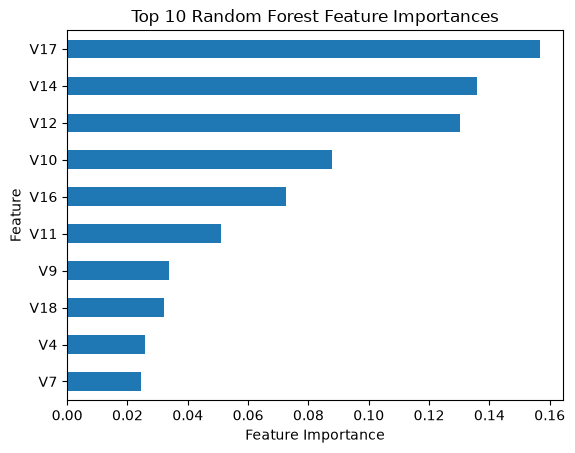

In [28]:
top_features = feature_importance.head(10)

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()